- 在matplotlib中，Axes对象是最重要的对象之一，Axes对象依赖Figure对象工作，而依赖Axes工作的对象很多，包括Axis，Artist等对象。本部分内容主要讲解Axes对象的创建，Axes对象的使用，以及他与依赖的对象、被依赖对象的关系。

``` text
pyplot的对象管理：
    FigureManager
        |-Figure
            |-Axes
                |-Artist
                    |-Line2D
                    |-Patch
                    |-Legend
                    |-Text
                    |-_BaseImage
                    |-Table
                    |-OffsetBox
                    |-AnnotationBbox
                    |-Collection
                    |-QuiverKey
```

- Figure与Figure对象关系结构
    - 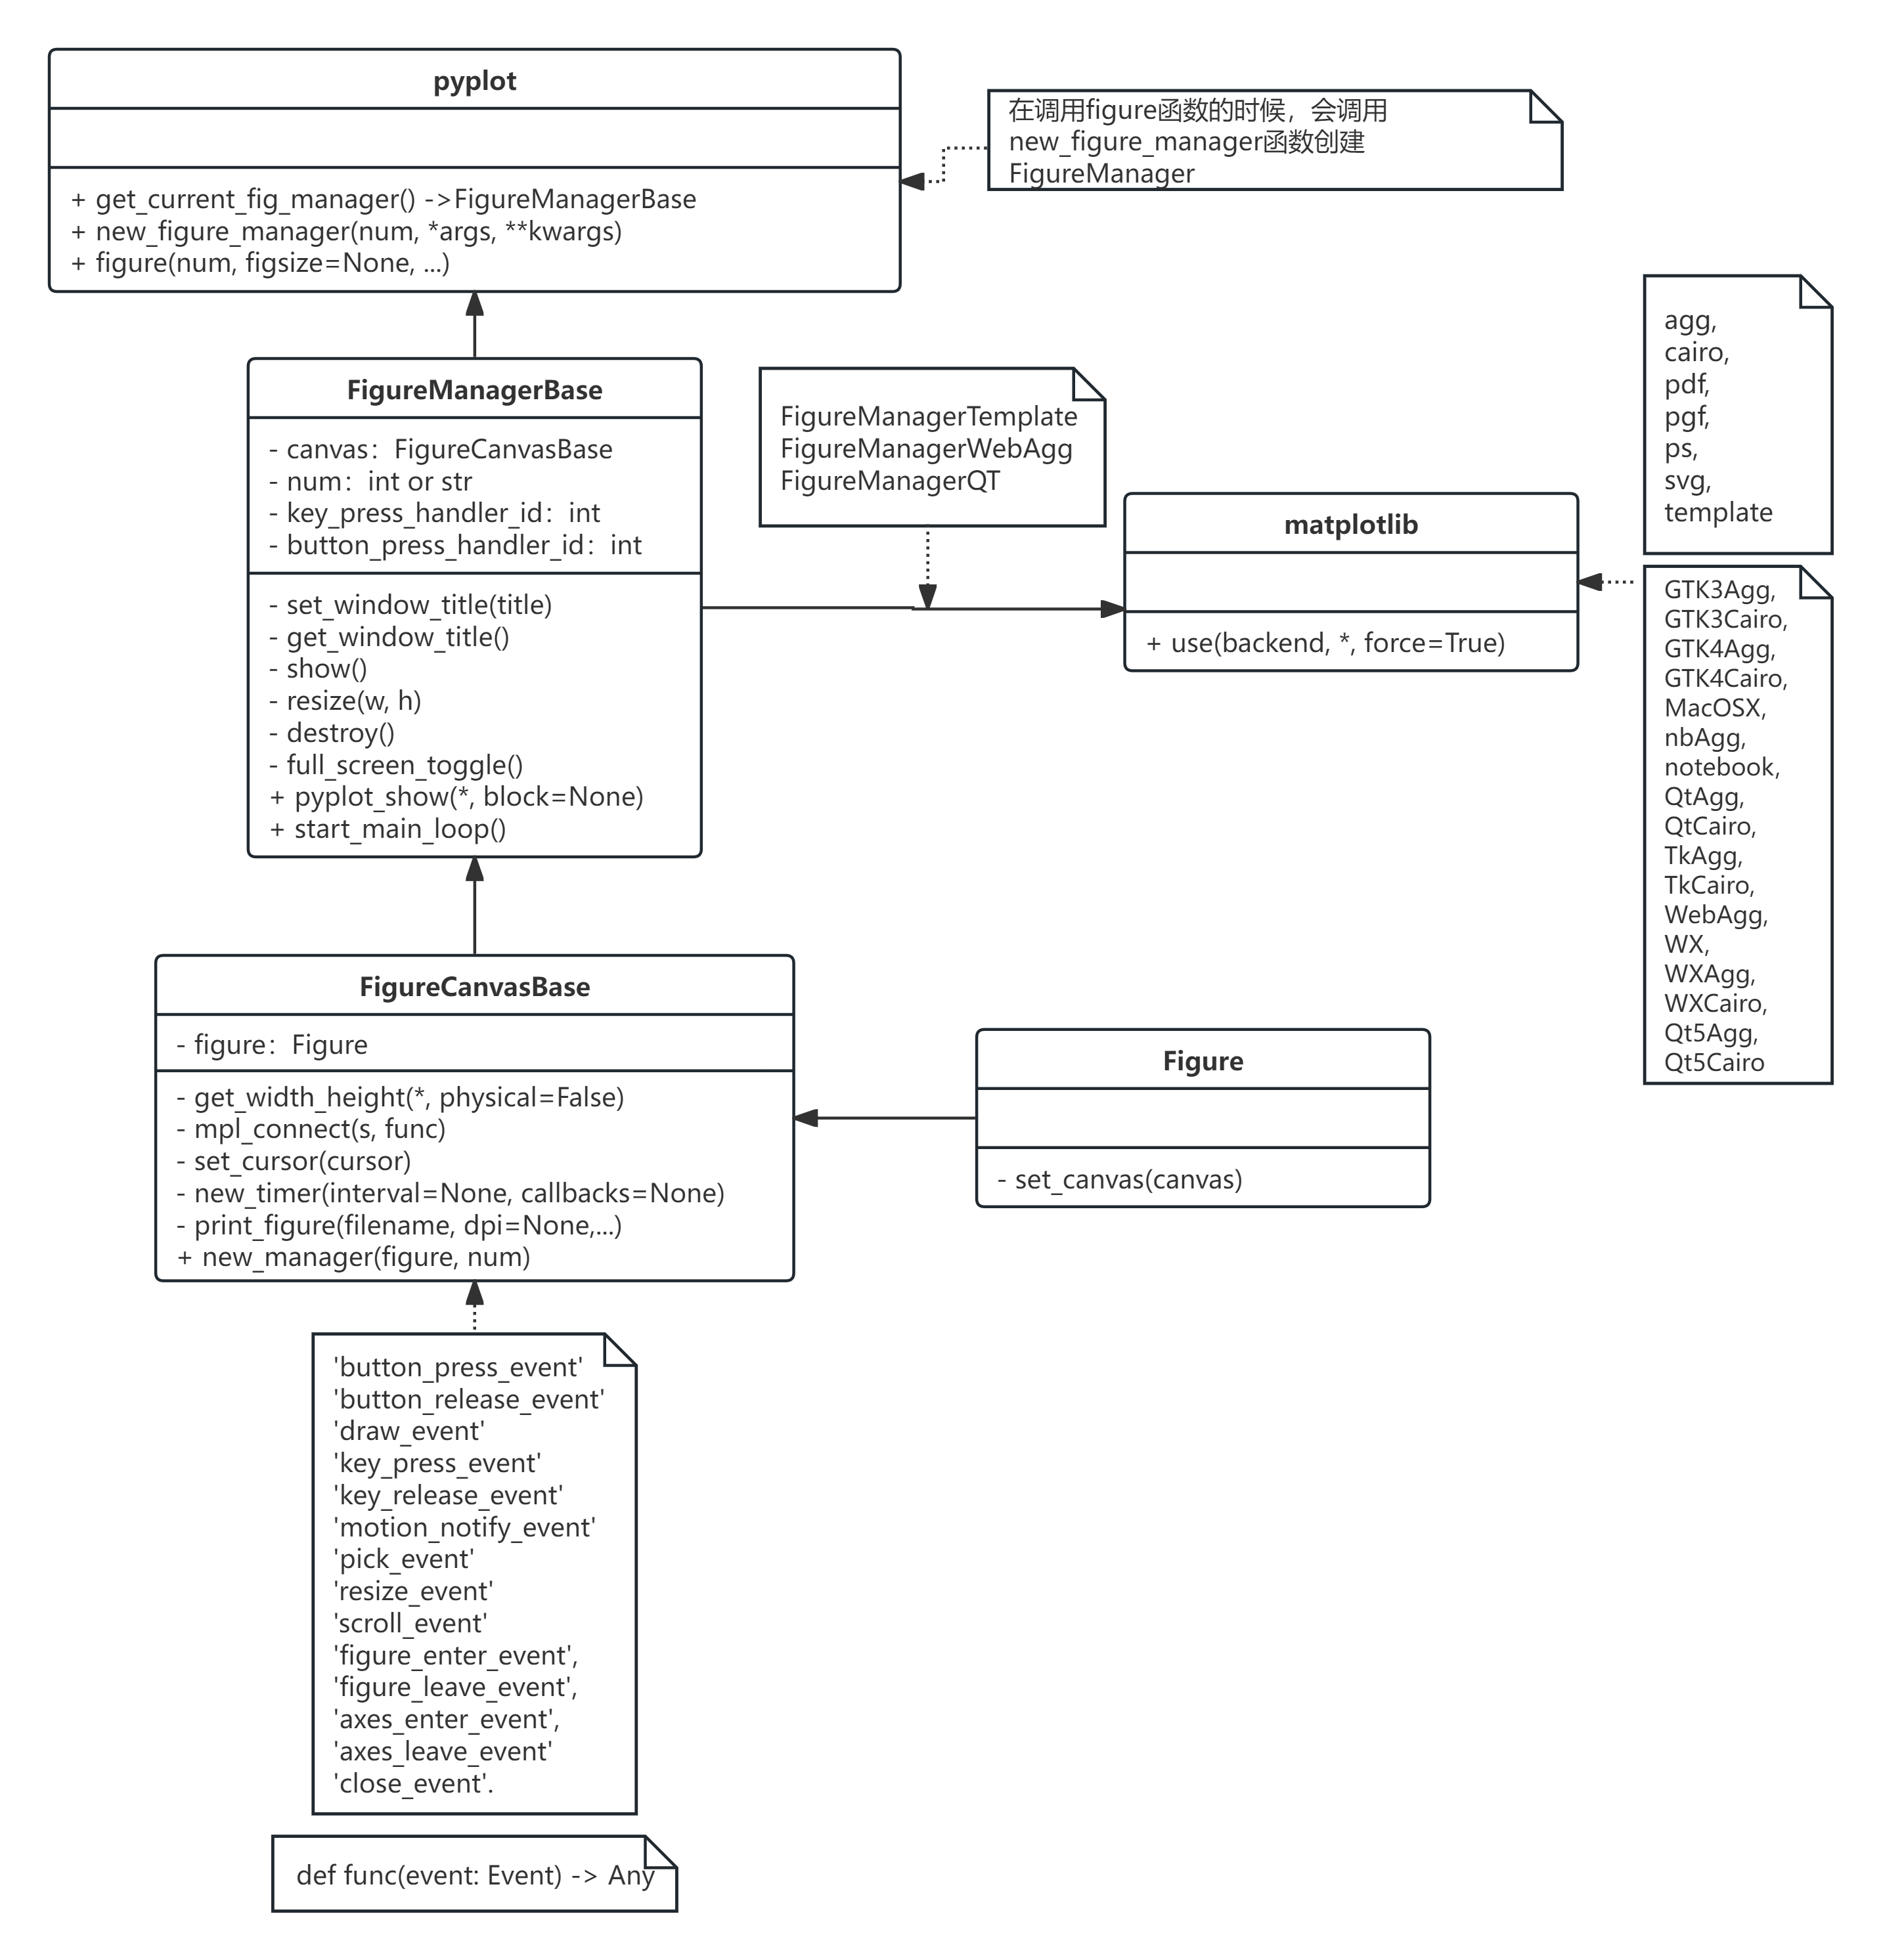

# 1. Axes对象构建与外观设置

## 1.1. Figure对象

### (1) Figure对象自动创建

- 在matplotlib的pyplot模块提供了figure函数创建Figure对象（见前面的内容讲解，这里不重复讲解），该函数创建了Figure对象，并管理Figure对象，使用pyplot的gcf()可以随时访问创建的Figure对象。
- 而且在matplotlib.pyplot很多函数中，还会自动创建Figure对象，甚至包括Axes对象。这些对象都会被matplotlib.pyplot管理, 被管理的Axes对象可以使用gca()函数访问。

自动创建的Figure对象 Figure(640x480) <class 'matplotlib.figure.Figure'>
自动创建的Axes对象 Axes(0.125,0.11;0.775x0.77) <class 'matplotlib.axes._axes.Axes'>


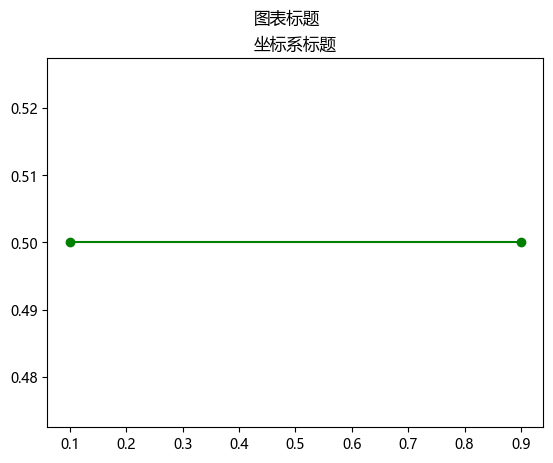

In [8]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft YaHei"]

plt.plot([0.1, 0.9], [0.5, 0.5], "go-")   # 自动创建Figure对象与Axes对象

print("自动创建的Figure对象", plt.gcf(), type(plt.gcf()))
print("自动创建的Axes对象", plt.gca(), type(plt.gca()))
# 可以使用这些对象
plt.gcf().suptitle("图表标题")
plt.gca().set_title("坐标系标题")
plt.show()

### (2) 使用Figure构造器创建对象

- Figure构造器的原型定义与参数说明：

```python
class matplotlib.figure.Figure(
    figsize=None, # 图表大小，参数格式(w, h)，单位英寸（inches）,元素类型是float。
    dpi=None,  # 设置分辨率，就是每英寸的像素个数，figsize * dpi就是最终输出的图表像素大小。参数是float类型。
    *, # 分隔符，前面的参数可以使用位置参数或者关键字参数。但是后面的参数必须是关键字参数
    facecolor=None, # 图表颜色,参数是颜色类型（matplotlib支持的颜色格式，可以是元组、字符串等）
    edgecolor=None, # 图表的边界颜色，参数是颜色类型.
    linewidth=0.0,  # 图表的边框(frame)宽度，参数是float类型。
    frameon=None, # 是否显示边框, 参数是bool类型。
    subplotpars=None,   # 设置子图(subplot)的参数，参数是SubplotParams类型。默认是None，使用rcParams["figure.subplot.*"]中的设置
    tight_layout=None,  # 设置图表中对象是否使用紧凑布局。该参数是bool类型。默认值是False。
    constrained_layout=None, # 该参数设置是否使用约束布局。不推荐使用，替代方式是layout='constrained'，该参数是bool类型。默认值是False。
    layout=None, # 设置图表的布局类型，该参数可以设置图表中对象的自动布局方式，取值{'constrained', 'compressed', 'tight', 'none', LayoutEngine, None}。默认值是None, 如果为None，则使用tight_layout与constrained_layout参数的布局方式。
    **kwargs  # 其他的Figure属性
)
```

- Figure构造器中的参数，在pyplot.figure函数中，很多都是一样（但是没有num：图表编号或者图表名称），在保存的Figure对象的时候，会使用savefig中的参数，导致保存后的图表与可视化现实的图表不同。

- Figure构造器中的很多参数可以不设置，而是使用rcParams中设置的参数值：
    - figsize：`rcParams["figure.figsize"]`，默认值(6.4, 4.8)。
    - dpi：`rcParams["figure.dpi"]`，默认值100.0。
    - facecolor：`rcParams["figure.facecolor"]`，默认值'white'。
    - edgecolor：`rcParams["figure.edgecolor"]`，默认值'white'。
    - frameon：`rcParams["figure.frameon"]`，默认值True。
    - subplotpars：`rcParams["figure.subplot.*"]`。
    - tight_layout：`rcParams["figure.autolayout"]`，默认值False。
    - constrained_layout：`rcParams["figure.constrained_layout.use"]`，默认值False。

In [1]:
import matplotlib.pyplot as  plt
import matplotlib.figure as  mfigure

fig = mfigure.Figure(figsize=(4, 3), facecolor="red")
fig.savefig("images/demo1.jpg")
# fig.show() 不能直接调用
fig.add_axes((0.1, 0.1, 0.8, 0.8))
plt.show() # 没有显示结果（Figure对象没有被pyplot管理）

# from IPython.display import display
# display(fig) # 没有显示结果
# # print(re)

- 代码说明：
    - 上面的代码能保存图表，但是使用Figure.show()会报错，使用pyplot.show()或者display没有结果。
    - display函数需要把图形数据转换为图像数据，并显示出来。上面仅仅是输出Figure对象的文本字符串，而不会显示图像。如果创建坐标系，则会显示图像，而返回None。
    - pyplot.show函数需要把图形渲染到后端。我们上面创建的图形实际没有后端。

### (3) 使用内置创建的FigureManager对象-get_current_fig_manager函数 

- 使用pyplot的get_current_fig_manager可以获取。
- 使用pyplot的figure函数创建的Figure对象。

In [3]:
import matplotlib.pyplot as plt

manager = plt.get_current_fig_manager()
print(manager)

fig = plt.figure()
fig_manager = fig.canvas.manager
print(fig_manager)

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

- 代码说明：
    - 每个FigureManager对象管理一个Figure对象。代码中的两个FigureManager不是同一个对象。

- FigureManager的主要作用是管理显示平台。不同的显示平台有不同的FigureManager实现。所有的FigureManager的实现都是FigureManagerBase的子类，常见的有：
    - FigureManagerTemplate（FigureManager）
    - FigureManagerQT（跨平台GUI）
    - FigureManagerTk （Python内置的GUI）
- 在matplotlib中可以使用use函数切换GUI平台。使用get_backend函数可以返回当前使用的GUI平台后端。

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.use("Qt5Agg")
print(mpl.get_backend())

mpl.use("TkAgg")
print(mpl.get_backend())

mpl.use("pdf")
print(mpl.get_backend())

Qt5Agg
TkAgg
pdf


- 也可以使用魔法指令指定GUI后端

In [10]:
%matplotlib inline
import matplotlib as mpl
print(mpl.get_backend())

%matplotlib qt
print(mpl.get_backend())


inline
qtagg


In [1]:
%matplotlib tk
import matplotlib as mpl
print(mpl.get_backend())

tkagg


- 代码说明：
    - 魔法指令中的后端模块支持，因操作系统不同而不同。
    - 在一个运行环境中，只能使用一种后端。
    - 目前魔法指令在不同平台的支持后端模块如下：
        - GUI
            - %matplotlib qt       # Qt5后端
            - %matplotlib qt5      # Qt5后端
            - %matplotlib qt4      # Qt4后端
            - %matplotlib gtk      # GTK后端
            - %matplotlib gtk3     # GTK3后端
            - %matplotlib gtk4     # GTK4后端
            - %matplotlib wx       # WxWidgets后端
            - %matplotlib tk       # Tkinter后端
            - %matplotlib osx      # macOS后端
        - 非交互式
            - %matplotlib notebook # 可缩放、平移图像的可交互式后端
            - %matplotlib inline   # 内嵌显示
            - %matplotlib agg      # 非交互式，只生成图片文件
            - %matplotlib svg      # 输出SVG格式（矢量图）
            - %matplotlib pdf      # 输出PDF格式
            - %matplotlib auto

- FigureManager对象提供了对GUI窗体的操作
    - set_window_title(title)   # 设置窗体的标题
    - get_window_title()        # 获取标题
    - show()                    # 显示窗体
    - resize(w, h)              # 设置窗体大小
    - destroy()                 # 释放窗体 
    - full_screen_toggle()      # 全屏的切换。

In [2]:
%matplotlib qt
import matplotlib.pyplot as plt

fig_manager = plt.get_current_fig_manager()
fig_manager.set_window_title("窗体标题")
fig_manager.resize(800, 600)

# 对Qt还可以访问toolbar，window与canvas
#  |- canvas：FigureCanvas
#  |- toolbar：qt.QToolBar
#  |- window : qt.QMainWindow
fig_manager.toolbar.hide() # 隐藏
fig_manager.full_screen_toggle()
plt.pause(2)  # 2秒后从全屏切换到正常
fig_manager.full_screen_toggle() 
manager.window.raise_()   # 直接窗体放在最前面

- 代码说明：
    - 使用魔法指令，自动显示，无需调用pyplot的show函数
    - 通过FigureManager可以设置后端的GUI相关组件。

- Figure对象与FigureManager对象的关系

Figure(640x480)


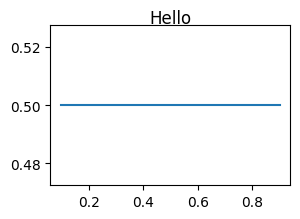

In [12]:
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import matplotlib
matplotlib.use('inline')
# 创建Figure
fig = Figure(figsize=(3, 2), dpi=100)
fig.suptitle("Hello")    
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot([0.1, 0.9], [0.5, 0.5])

###############################################
canvas = FigureCanvasAgg(fig)
fig.set_canvas(canvas)

manager = plt.get_current_fig_manager()
print(manager.canvas)
print(manager.canvas.figure)
manager.canvas = canvas


plt.show()


### (4) 通过FigureManager对象使用FigureCanvas对象

- FigureManager对象管理后端GUI，其中包含对画布的管理。
- 在matplotlib中所有画布都是FigureCanvasBase类型，根据不同的后端会继承FigureCanvasBase类实现不同的FigureCanvas。主要包含：
    - FigureCanvas：是FigureCanvasTemplate的别名。
    - FigureCanvasQT：多重继承FigureCanvasBase, QtWidgets.QWidget。

FigureCanvas的成员函数：
    - get_width_height(*, physical=False)        # 画布大小
    - mpl_connect(s, func)                       # 处理事件
    - set_cursor(cursor)：                       # 设置鼠标光标
    - new_timer(interval=None, callbacks=None)   # 定时器
    - print_figure(filename, dpi=None,...)       # 保存画布图像。 
FigureCanvas的类函数：
    - new_manager(figure, num)：创建FigureManager对象。

- 使用mpl_connect实现窗体的事件处理

In [6]:
import matplotlib
matplotlib.use('Qt5Agg')  # 明确指定后端
import matplotlib.pyplot as plt

def on_close(event):
    print('窗口关闭中...')

plt.plot([0.1, 0.9], [0.5, 0.5])
plt.show()
manager = plt.get_current_fig_manager()
manager.window.raise_()   # 直接窗体放在最前面
print(manager)
manager.canvas.mpl_connect('close_event', on_close)
from matplotlib.backend_tools import Cursors
from PyQt5 import QtCore, QtWidgets, QtGui
# manager.canvas.set_cursor(Cursors(5))  # 支持1-7一共7种鼠标贯标
plt.gcf().canvas.set_cursor(Cursors(5))
print(plt.gcf().canvas)
print(manager.canvas)

窗口关闭中...


- 代码说明:
    - 注意：某些后端可能会更改整个窗口的光标。某些后端可能不会改变鼠标光标。
    - FigureCanvasQTAgg也是双重继承：FigureCanvasQTAgg继承了FigureCanvasAgg与FigureCanvasQT：
        - FigureCanvasAgg：负责图相关的绘制格式
        - FigureCanvasQT：负责画布（本质是QWidgt）

- 使用FigureManager管理用户创建的Figure对象。

### (5) 保存图表

- Figure对象是独立工作的，可以现在在多个平台上，包括Jupyter Notebook或者 tkthinker，Qt，XWindow等，但是最原始的输出实际是图像格式，再把图像显示在不同平台上。保存Figure为图像就是用Figure对象的savefig函数。

- 我们在这儿再重复讲述找个函数，是因为我们站在Figure对象的独立性与其依赖的平台的关系角度，所以pyplot的figure函数中提供的参数可能与显示平台有关，我们通过保存的图像与显示的图像的差别来体验这一点。

- Figure对象的savefig函数的原型定义与参数说明：

```python
savefig(
    fname,   # 保存的图像文件名
    *, 
    transparent=None,   # 设置透明度
    dpi='figure',    # 像素精度(每英寸的像素数)
    format=None,    # 设置文件保存的格式，如果该参数没有设置，这使用fname的扩展名来确定文件格式。
    metadata=None, # 保存图像的元数据（比如文件的所有这）
    bbox_inches=None,  # 设置Foigure对象的边框，类型str或者Bbox，str取值tight。Bbox对象参数[[xmin, ymin], [xmax, ymax]]
    pad_inches=0.1,   # 图形变宽
    facecolor='auto',  # Figure颜色
    edgecolor='auto',  # 边界颜色
    backend=None,  # 后端绘图方式，与FigureManager有关，分静态后端与交互式后端。
    **kwargs
)
```

- Figure显示在定制的后端

inline


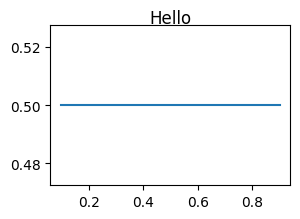

In [3]:
# %matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
# from matplotlib.backends.backend_qtagg import FigureCanvasQTAgg 
import matplotlib
print(matplotlib.get_backend())
matplotlib.use('inline')

########################## 
# 创建Figure
fig = Figure(figsize=(3, 2), dpi=100)
fig.suptitle("Hello")    
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot([0.1, 0.9], [0.5, 0.5])

######################把图表显示在后端指定的平台上
# 创建canvas,并绑定Figure与Canvas的关系：Canvas是Figure的容器
canvas = FigureCanvasAgg(fig)
fig.set_canvas(canvas)

# 获取FigureManager对象，并绑定Canvas（同时也绑定）
current_manager = plt.get_current_fig_manager()
# print(current_manager.canvas)
current_manager.canvas = canvas


# current_manager.pyplot_show()
print(canvas)
print(current_manager)
plt.show()



- 代码说明：
    - 上面我们提前说明把图表显示在平台上的过程，如果保存为文件，则上面与平台相关的内容是多余的。下面是图表的保存的实现。

In [2]:
from matplotlib.figure import Figure

fig = Figure(figsize=(3, 2), dpi=100)
fig.suptitle("Hello")    
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot([0.1, 0.9], [0.5, 0.5])

fig.savefig("images/demo2.jpg")

### (6) 创建FigureManager与FigureCanvas对象

- FigureManager对象与FigureCanvas对象是相互相关的。创建FigureManager与FigureCanvas对象的关键是需要处理几个关系：
    - FigureManager与pyplot的关系。
    - FigureManager与FigureCanvas的关系。
    - FigureManager、FigureCanvas与Figure对象的关系。

- FigureManager与Figure的关系。

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure
from matplotlib import _pylab_helpers
import numpy as np

mpl.use("Qt5Agg")  # 必须设置

fig = Figure(figsize=(3, 2), dpi=100)
fig.suptitle("Hello")    
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot([0.1, 0.9], [0.5, 0.5])

manager = plt.new_figure_manager(num=1)  # 自动判别平台，创建管理器
manager.canvas.figure = fig
# manager.canvas.draw()  # 强制刷新
_pylab_helpers.Gcf.set_active(manager)   # 激活就可以使用。

plt.plot([0.1, 0.9], [0.8, 0.5])   # 可以通过pyplot使用前面创建的Figure对象。

plt.show()


- 代码说明：
    - `_pylab_helpers.Gcf.set_active(manager)`代码通过matplotlib内部底层的辅助工具_pylab_helpers激活FigureManager为当前管理器。
    - `plt.plot([0.1, 0.9], [0.8, 0.5])`代码的结果，说明创建的新的Figure对象已经被pyplot管理，并且通过pyplot可以直接使用。
    - 代码中我们使用了`new_figure_manager`函数创建新的FigureManager对象。
    - 上面代码适合具有GUI后端的管理器使用，对非交互式后端不适合，因为激活新的FigureManager
    - 在上面代码中，没有创建FigureCanvas对象，

- 创建FigureCanvas
    - 下面提供两个例子：一个是GUI后端，一个是inline后端，这是我们常见的两种后端模式。 

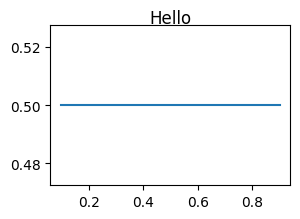

In [2]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.backends.backend_agg import FigureManagerBase
from matplotlib.figure import Figure
from matplotlib import _pylab_helpers
import numpy as np

mpl.use("inline")   # 'agg', 'svg', 'pdf', 'ps'，非交互式与平台无关

fig = Figure(figsize=(3, 2), dpi=100)
fig.suptitle("Hello")    
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot([0.1, 0.9], [0.5, 0.5])

canvas = FigureCanvasAgg(fig)
# fig.set_canvas(canvas)
canvas.figure=fig
manager = plt.new_figure_manager(num=1)  # 自动判别平台，创建管理器
manager.canvas = canvas
# manager.canvas.figure = fig

# _pylab_helpers.Gcf.set_active(manager)  
_pylab_helpers.Gcf._set_new_active_manager(manager)
canvas.draw()
# canvas.print_figure("demo")   # png
# fig.savefig("demo")

plt.savefig("demo.pdf")  # pyplot起作用了。
plt.show()

- 代码说明：
    - 创建FigureCanvasAgg对象时，通过构造器就绑定了Canvas与Figure的关系（`canvas = FigureCanvasAgg(fig)`），Figure依赖画布工作。
        - 还可以使用figure对象的set_canvas函数绑定：`fig.set_canvas(canvas)`
        - 也可以使用canvas的figure属性直接绑定：`canvas.figure=fig`或者`manager.canvas.figure = fig`
        - 注意：上面绑定关系只需要一种就行，我们采用了构造器模式。
    - `manager.canvas = canvas`绑定Canvas与FigureManager的关系。
    - `_pylab_helpers.Gcf._set_new_active_manager(manager)`代码，是设置pyplot的当前激活的FigureManager管理器。
    - 对inline后端的情况下，不能使用`_pylab_helpers.Gcf.set_active(manager)`激活当前FigureManager管理器，而是还需要处理一些时间绑定。所以一般使用`_set_new_active_manager`函数激活。

- 不同的后端使用的FigureManager与FigureCanvas有不同的实现。所以在创建的时候，一般会获取后端类型，创建不同的FigureManager对象与FigureCanvas对象。

- 下面是使用Qt5Agg后端，创建FigureCanvas对象。

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib import _pylab_helpers
import numpy as np
from matplotlib.backends.backend_qtagg import FigureCanvasQTAgg  
from matplotlib.backends.backend_qt import FigureCanvasQT, FigureManagerQT
'''
FigureCanvasQT与FigureCanvasQTAgg的关系是继承关系：
    |- class FigureCanvasQTAgg(FigureCanvasAgg, FigureCanvasQT):
    |- 增加了FigureCanvasAgg图像的格式处理部分功能。
'''
mpl.use("QtAgg")

fig = Figure(figsize=(3, 2), dpi=100)
fig.suptitle("Hello")    
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot([0.1, 0.9], [0.5, 0.5])

canvas = FigureCanvasQTAgg(fig)   # FigureCanvasQT(fig)
manager = plt.new_figure_manager(num=1)  # 自动判别平台，创建管理器
manager.canvas = canvas

manager.window.setCentralWidget(canvas)   # 添加到窗体中。

_pylab_helpers.Gcf.set_active(manager)  # 被pyplot管理
# _pylab_helpers.Gcf._set_new_active_manager(manager)

plt.savefig("demo.pdf")  # pyplot起作用了。
plt.show()

- 代码说明：
    - 因为代码中是用户创建的`FigureCanvasQTAgg`对象，FigureCanvasQTAgg对象，本质是QWidget组件，使用创建的Canvas替换默认的Canvas后，没有替换窗体中显示的FigureCanvasQTAgg对象，在理解QtAgg的工作原理的情况下，我们可以利用Qt的技术解决掉画布不显示的问题。代码是：`manager.window.setCentralWidget(canvas)`

- 下面是使用Qt5Agg后端，创建FigureManager对象。

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib import _pylab_helpers
import numpy as np
from matplotlib.backends.backend_qtagg import FigureCanvasQTAgg  
from matplotlib.backends.backend_qt import FigureCanvasQT, FigureManagerQT
mpl.use("QtAgg")

fig = Figure(figsize=(3, 2), dpi=100)
fig.suptitle("Hello")    
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot([0.1, 0.9], [0.5, 0.5])

canvas = FigureCanvasQTAgg(fig)   # FigureCanvasQT(fig)
manager = FigureManagerQT(canvas=canvas, num=1)

_pylab_helpers.Gcf.set_active(manager)  # 被pyplot管理
# _pylab_helpers.Gcf._set_new_active_manager(manager)

plt.savefig("demo.pdf")  # pyplot起作用了。
plt.show()

- 代码说明：
    - FigureCanvasQTAgg对象负责画布的相关绘制工作，在Qt中就是QWidget组件。同时负责相关事件处理。
    - FigureManagerQT对象主要负责窗体。
    - FigureManagerQT与FigureCanvasQTAgg的关系在构造器通过参数传递来完成，所以没有像上一个代码例子，需要通过setCentralWidget函数来强制设置。
    - 通过`_pylab_helpers.Gcf.set_active(manager)`设置后，我们在利用pyplot的函数操作，都会影响到当前的Axes与Figure对象。

## 1.2. Axes对象的创建

- Axes对象创建对用户来说有两种方式：
    - 使用Axes构造器构造。
    - 使用Matplotlib的提供的函数创建。

- 使用构造器创建的对象，我们需要处理与Figure的关系，因为Axes使用Figure对象作为容器或者画布。使用matplotlib函数创建的对象，函数一般都会自动维护与Figure对象的关系，甚至在Figure不存在的情况下，还会自动创建Figure对象。

### (1) 使用构造器创建Axes对象

- Axes对象最终都是由构造器创建的，在matplotlib中使用工厂模式，提供函数来完成Axes对象的创建，并且pylplot的函数是对这些工厂函数的二次封装。使用函数的好处是隐藏很多对象关系维护的细节，使得用户使用起来简单高效。
- 本节我们使用构造器创建Axes对象，主要是关注Axes对象与Figure的关系，以及pyplot对Axes对象的管理。下面是Axes对象的构造器原型定义与参数说明：

```python
class matplotlib.axes.Axes(
    fig,                # Axes所在的图表Figure对象
    *args,              # (left, bottom, width, height)格式或者Bbox格式的坐标系位置与大小。 
    facecolor=None,     # 坐标系的背景色，参数是matplotlib可用的颜色格式。
    frameon=True,       # 是否绘制坐标系的边框线
    sharex=None,        # 参数是Axes对象，用来设置一样的x轴参数
    sharey=None,        # 参数是Axes对象，用来设置一样的y轴参数
    label='',           # 坐标系的标签
    xscale=None,        # x轴的缩放方式，包含"asinh"，"function"，"functionlog"，"linear"，"log"，"logit"，"symlog"
    yscale=None,        # y坐标轴的缩放方式
    box_aspect=None,    # 设置x，y轴框固定的纵横比，即高宽比
    forward_navigation_events='auto',   #当多个 Axes 重叠或嵌套时，用于控制导航事件（如缩放、平移）的传播行为。
    **kwargs)  # 其他参数：title, xlabel,ylabel, xlim, ylim, xticks, yticks等。 
```

- 说明：
    - 上述参数fig与*arg是必须的，其他参数可选，而且大部分参数在通常情况下都不使用，而是通过Axes对象的来设置。
    - 前面我们也说过，在matplotlib中，对图形等对象的属性设置一般通过三种方式：
        - 函数与构造器参数。
        - 使用`**kwargs`关键字参数，一般都是来自创建对象的属性。
        - 直接使用创建对象设置。
    - 提示：参数设置太麻烦，代码不容易维护，我们推荐使用对象来设置达到一样的目的。

- Axes对象可以使用Figure对象的add_axes函数绘制到Figure对象。add_axes函数的原型定义与参数说明如下：

```python
Figure.add_axes(
    *args,         # rect, projection, polar，sharex, sharey, label等参数或者Axes对象
    **kwargs)      # 与Axes构造中参数一样。
```

- add_axes两种使用方式：
    - `add_axes(rect, projection=None, polar=False, **kwargs)`
    - `add_axes(ax)`


- 提示：
    - 在前面我们介绍了Figure创建的几种方式，其中使用pyplot的figure函数是最简洁，并且能达到我们的所有目的。在后面我们都使用这种方式创建Figure对象。

2925334433616 2925334433616
2925334434256 2925334434256
2925334434256 2925334434256
2925334433616 2925334433616


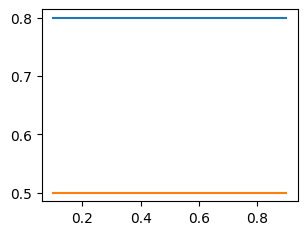

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

fig = plt.figure(figsize=(3.2, 2.4))
print(id(plt.gcf()), id(fig))
ax = Axes(fig, [0.1, 0.1, 0.8, 0.8])
fig.add_axes(ax)
# plt.sca(ax)  #
ax.plot([0.1, 0.9], [0.8, 0.8])
print(id(plt.gca()), id(ax))

# plt.sca(ax)
plt.plot([0.1, 0.9], [0.5, 0.5])
# plt.show()
# plt.sca(ax)  # 注销这个语句，后面的代码输出会有不同
print(id(plt.gca()), id(ax))   # 当前Axes不是我们创建的Axes（访问当前Axes，导致当前Figure切换到与当前Axes匹配的Figure对象）
print(id(plt.gcf()), id(fig))  # 输出的内容不同。

- 代码说明:
    - 上面代码中，`plt.show()`使用的时候需要慎重，因为是显示所有Figure，在显示过程中，会导致当前Figure与Axes对象切换（一般是切换到最后一个）

### (2) 使用函数创建对象

- 在pyplot中提供的坐标系创建函数基本上都是对Axes对象中的坐标系创建函数的二次封装。在pyplot中函数都是默认当前Figure与当前Axes对象，并自动维护他们的关系。
- 回顾pyplot中相关函数：
    - `matplotlib.pyplot.axes(arg=None, **kwargs)`
    - `matplotlib.pyplot.subplot(*args, **kwargs)`
    - `matplotlib.pyplot.subplots(nrows=1, ncols=1, *, sharex=False, sharey=False, squeeze=True, width_ratios=None, height_ratios=None, subplot_kw=None, gridspec_kw=None, **fig_kw)`
    - `matplotlib.pyplot.subplot2grid(shape, loc, rowspan=1, colspan=1, fig=None, **kwargs)`
    - `matplotlib.pyplot.subplot_mosaic(mosaic, *, sharex=False, sharey=False, width_ratios=None, height_ratios=None, empty_sentinel='.', subplot_kw=None, gridspec_kw=None, per_subplot_kw=None, **fig_kw)`

- 在Figure对象中也提供了类似的函数：
    - `Figure.add_axes(*args, **kwargs)`
    - `Figure.add_subplot(*args, **kwargs)`
    - `Figure.subplots(nrows=1, ncols=1, *, sharex=False, sharey=False, squeeze=True, width_ratios=None, height_ratios=None, subplot_kw=None, gridspec_kw=None)`
    - `Figure.add_gridspec(nrows=1, ncols=1, **kwargs)`
    - `Figure.subplot_mosaic(mosaic, *, sharex=False, sharey=False, width_ratios=None, height_ratios=None, empty_sentinel='.', subplot_kw=None, per_subplot_kw=None, gridspec_kw=None)`

- 我们看的出来Figure中的函数都在pyplot中被一一对应二次封装。在前面已经使用过pyplot中的Axes创建函数，对Figure中的相关函数我们这儿不再介绍。

## 1.3. Axes对象的属性

### (1) viewLim属性

- viewLim是Axes对象的一个重要属性，它表示当前视图的数据坐标范围。当用户进行以下操作时，viewLim 会自动更新：
    - 缩放（鼠标滚轮或工具栏）
    - 平移（鼠标拖拽）
    - 通过 set_xlim()/set_ylim() 手动设置范围

- viewLim属性是Bbox类型，Bbox的使用包含:
    - 构建Bbox对象。
        - 使用构造器：`matplotlib.transforms.Bbox(points, **kwargs)`
            - points是`[[x1, y1], [x2, y2]]`格式的两个点。
        - 使用类函数构建：
            - `static from_bounds(x0, y0, width, height)`
            - `static from_extents(left, bottom, right, top, minpos=None)`
                - minpos用来防止left，bottom，right，top等参数是负数。
    - 对象的数据访问，主要是使用属性的方式，常见属性。
        - p0, p1：返回两个点。
        - x0, x1, y0, y1：返回两个点的坐标值
        - bounds：返回数据 (x0, y0, width, height)。
        - width, height:返回宽高。
    - 简单的操作：
        - contains(x, y)：Bbox是否包含某个点。

- 属性包含访问与设置两种方式

In [10]:
%matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.transforms import Bbox

fig = plt.figure(figsize=(3.2, 2.4))

ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

ax.plot([0.1, 0.9], [0.8, 0.8])

print(ax.viewLim)

ax.set_xlim([0, 5])
ax.set_ylim([0, 5])

plt.show()

Bbox(x0=0.06, y0=0.756, x1=0.9400000000000001, y1=0.8440000000000001)


- 代码说明：
    - 设置新的viewLim使用set_xlim与set_ylim函数。
    - 使用GUI后端，并在窗体中操作观看viewLim的变化（移动，缩放）。
    - 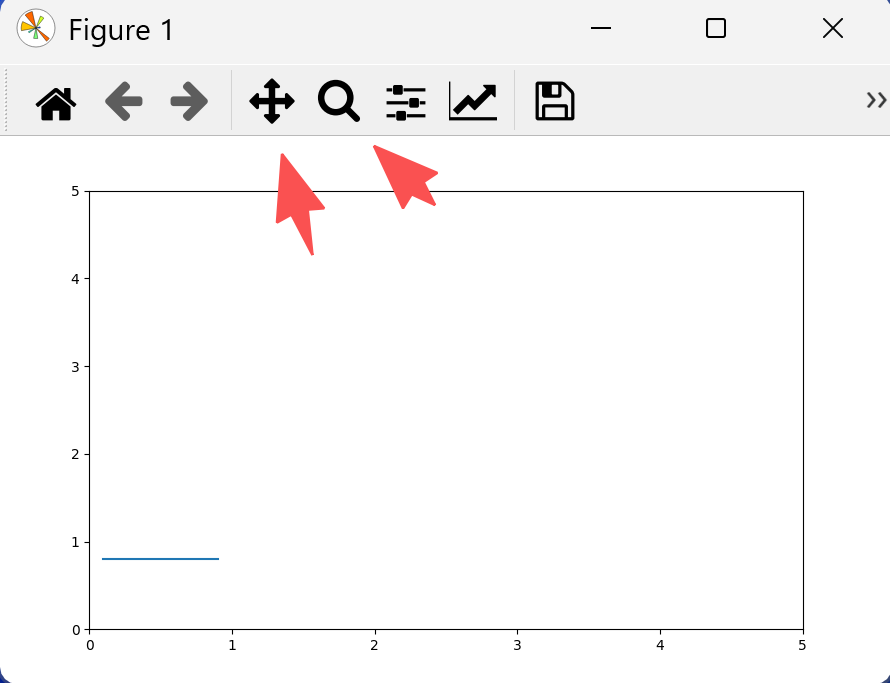

- 下面演示代码改变视图的变换

In [17]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.transforms import Bbox
mpl.use('Qt5Agg')

fig = plt.figure(figsize=(3.2, 2.4), dpi=250)

ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

ax.plot([0.1, 0.9], [0.8, 0.8])

saved_view1 = ax.viewLim.frozen()
plt.pause(2)
ax.set_xlim([0, 2])
ax.set_ylim([0, 2])
saved_view2 = ax.viewLim.frozen()
plt.pause(2)
ax.set_xlim([0, 3])
ax.set_ylim([0, 3])
saved_view3 = ax.viewLim.frozen()
plt.pause(2)
ax.set_xlim([0, 5])
ax.set_ylim([0, 5])
plt.pause(2)
ax.set_xlim(saved_view3.intervalx)
ax.set_ylim(saved_view3.intervaly)
plt.pause(2)
ax.set_xlim(saved_view2.intervalx)
ax.set_ylim(saved_view2.intervaly)
plt.pause(2)
ax.set_xlim(saved_view1.intervalx)
ax.set_ylim(saved_view1.intervaly)
plt.show()

### (2) dataLim属性

- 与viewLim属性一样，dataLim是 Matplotlib中Axes对象的一个重要属性，用于获取当前坐标轴中所有数据点的数据范围边界。
    - 该属性基于当前绘制的所有图形元素（线、散点、柱状图等）自动计算数据范围。
    - 返回一个 包含边界信息的Bbox对象，包含 (xmin, ymin, xmax, ymax)
    - 注意：是包含所有图形的数据范围边界（综合计算）。

- dataLim 与 viewLim 的区别：
    - dataLim：数据的实际范围（由数据决定）
    - viewLim：当前显示的视图范围（可能被 set_xlim/set_ylim 改变），可是使用交互方式改变。

In [5]:
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

# 初始绘制
ax.plot([1, 2, 3], [1, 4, 9])
print(f"第一次绘制后: {ax.dataLim}")

plt.pause(2)
# 添加新数据（不自动更新显示范围）
ax.plot([10, 11], [100, 121], 'r-')
print(f"添加新数据后: {ax.dataLim}")
plt.pause(2)

# 需要调用相关方法来更新视图
ax.relim()      # 重新计算数据限制
plt.pause(2)
ax.autoscale()  # 自动调整坐标轴范围
print(f"更新后: {ax.dataLim}")

plt.show()

第一次绘制后: Bbox(x0=1.0, y0=1.0, x1=3.0, y1=9.0)
添加新数据后: Bbox(x0=1.0, y0=1.0, x1=11.0, y1=121.0)
更新后: Bbox(x0=1.0, y0=1.0, x1=11.0, y1=121.0)


- 代码说明：
    - 使用Axes对象的relim函数可以强制刷新dataLim属性的值。
    - 使用Axes对象的autoscale函数可以强制刷新viewLim属性的显示状态（根据dataLim更新显示范围）。
    - 一般绘制函数也会自动调用relim与autoscale来完成相应的操作。
    - 典型的数据更新模式：
        - 更新数据：`line.set_data(new_x, new_y)`
        - 重新计算数据边界：`ax.relim()`
        - 自动调整显示范围：`ax.autoscale()`
        - 重绘图：`plt.draw()`

In [27]:
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

[line] = ax.plot([], [])
print("空图形")
plt.pause(2)
line.set_data([1, 2, 3], [1, 4, 9])
print("设置数据")
# plt.draw()     # 需要重新计算并更新后，绘制有效。
plt.pause(2)
ax.relim()      # 重新计算数据限制
ax.autoscale()  # 自动调整坐标轴范围
print("刷新")
plt.pause(2)
plt.draw()
print("绘制")
# plt.show()

空图形
设置数据
刷新
绘制


### (3) spines属性

- spines 是 Matplotlib 中 Axes 对象的边界线属性，用于控制坐标轴框架的外观和行为。每个坐标轴通常有4个spine：上、下、左、右。

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1])

print(ax.spines)


- 代码说明：
    - spines的类型是`matplotlib.spines.Spines(**kwargs)`,继承MutableMapping类，本质是一个字典类型。
        - 可以按照字典的使用方式使用

In [31]:
print(ax.spines.keys())
print(list(ax.spines.keys()))
for key in ax.spines.keys():
    print(key)
print(ax.spines.values())
print(dict(ax.spines))

KeysView(<matplotlib.spines.Spines object at 0x00000205FC8B96D0>)
['left', 'right', 'bottom', 'top']
left
right
bottom
top
ValuesView(<matplotlib.spines.Spines object at 0x00000205FC8B96D0>)
{'left': <matplotlib.spines.Spine object at 0x00000205FCBE5450>, 'right': <matplotlib.spines.Spine object at 0x00000205FCBE5310>, 'bottom': <matplotlib.spines.Spine object at 0x00000205FCBE5950>, 'top': <matplotlib.spines.Spine object at 0x00000205FCBE5F90>}


- 我们直接按照字典的使用方式来使用每个spine对象，spine对象的常见属性：
    - alpha
    - bounds：(low: float, high: float)
    - color
    - label
    - linestyle
    - linewidth
    - position
        - 二元组：(类型：str, 位置：float)，类型包含：
            - outward：指定的值是points，负值表示在数据区内部。
            - axes：指定0-1之间的值，0.5表示在坐标系中间
                - (axes, 0.5) == "center"
            - data：指定数据坐标系的位置
                - (data, 0.0) == "zero"
    - visible: 设置是否可见。

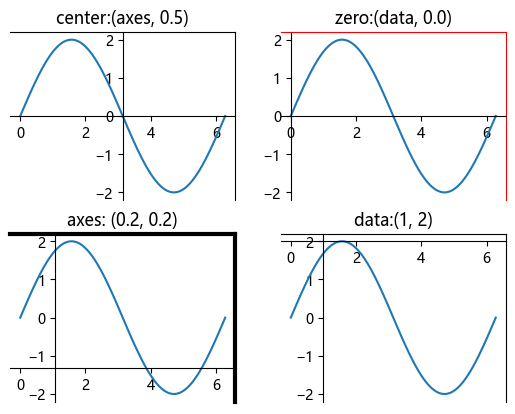

In [35]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2*np.pi, 100)
y = 2 * np.sin(x)

fig, ax_dict = plt.subplot_mosaic(
    [['center', 'zero'],
     ['axes', 'data']]
)

ax = ax_dict['center']
ax.set_title("center:(axes, 0.5)")
ax.plot(x, y)
ax.spines[['left', 'bottom']].set_position('center')
# ax.spines[['top', 'right']].set_visible(False)

ax = ax_dict['zero']
ax.set_title("zero:(data, 0.0)")
ax.plot(x, y)
ax.spines[['left', 'bottom']].set_position('zero')
# ax.spines[['top', 'right']].set_visible(False)
ax.spines[['top', 'right']].set_color("red")

ax = ax_dict['axes']
ax.set_title("axes: (0.2, 0.2)")
ax.plot(x, y)
ax.spines.left.set_position(('axes', 0.2))
ax.spines.bottom.set_position(('axes', 0.2))
# ax.spines[['top', 'right']].set_visible(False)
ax.spines[['top', 'right']].set_linewidth(3)

ax = ax_dict['data']
ax.set_title("data:(1, 2)")
ax.plot(x, y)
ax.spines.left.set_position(('data', 1))
ax.spines.bottom.set_position(('data', 2))
# ax.spines[['top', 'right']].set_visible(False)


- 代码说明：
    - 坐标轴的位置有两种参考单位：data坐标系(data)与标准坐标系（axes）。
    - 通过spines属性，可以很好的设置坐标轴的外观。

# 2. 图表的Axes布局

# 3. Axes的图形绘制

# 4. Axes中使用图形对象(Artist)

# 5. Axes的坐标轴与刻度

# 5. Axes的交互操作

# 6. Axes的变换